In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error

In [3]:
df=pd.read_csv('Advertising Budget and Sales.csv')
df.head(1)

,Unnamed: 0,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),Sales ($)
0,1,230.1,37.8,69.2,22.1


In [4]:
# حذف عمود الترقيم التلقائي لأنه يفسد دقة النموذج
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])
    

# =====================================================================
# 2. هندسة الميزات (Feature Engineering)
# =====================================================================
# إضافة متغير تفاعلي بين التلفزيون والراديو لرفع دقة النموذج بشكل ملحوظ
df['TV_Radio_Interaction'] = df['TV Ad Budget ($)'] * df['Radio Ad Budget ($)']

# فصل المتغيرات المستقلة (X) عن المتغير التابع (y)
X = df.drop(columns=['Sales ($)'])
y = df['Sales ($)']

np.int64(0)

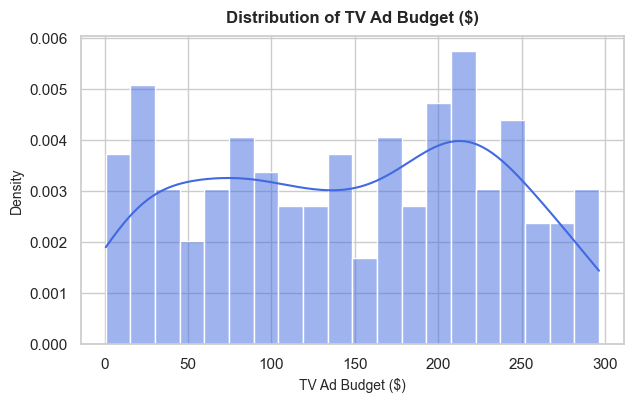

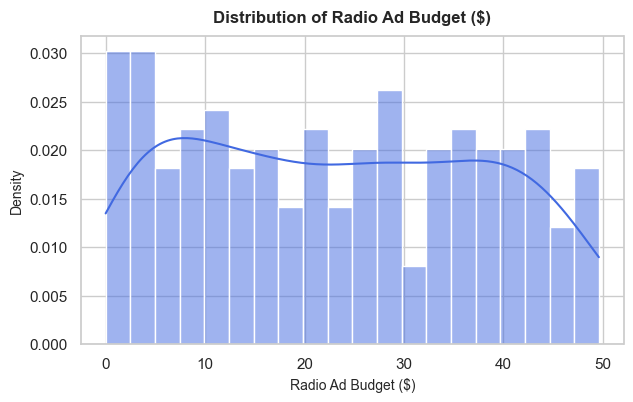

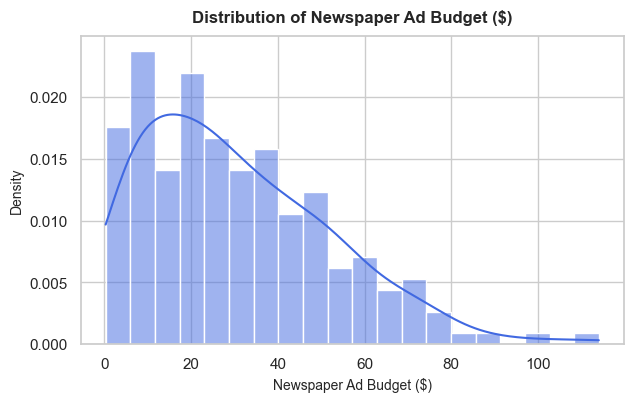

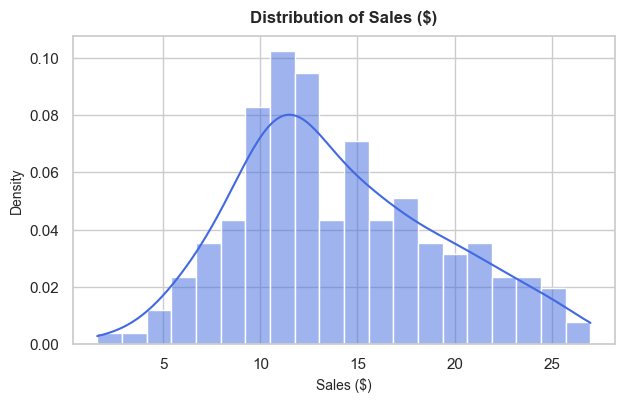

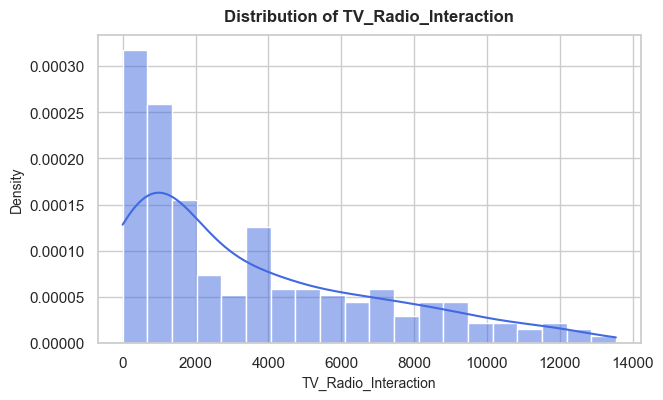

In [8]:
sns.set_theme(style="whitegrid")

# 2. تحديد الأعمدة المراد رسم توزيعها
columns = ['TV Ad Budget ($)', 'Radio Ad Budget ($)', 'Newspaper Ad Budget ($)', 'Sales ($)', 'TV_Radio_Interaction']

# 3. حلقة تكرارية للمرور على الأعمدة ورسمها
for col in columns:
    # التحقق من وجود العمود في البيانات أولاً لتجنب الـ KeyError
    if col in df.columns:
        plt.figure(figsize=(7, 4)) # تحديد حجم مناسب لكل رسمة لضمان وضوح البيانات
        
        # الاستخدام الصحيح والحديث لرسم التوزيع والمنحنى الملاءم
        sns.histplot(df[col], kde=True, color="royalblue", bins=20, stat="density")
        
        # إضافة العناوين وتنسيق الخطوط
        plt.title(f"Distribution of {col}", fontsize=12, fontweight='bold', pad=10)
        plt.xlabel(col, fontsize=10)
        plt.ylabel("Density", fontsize=10)
        
        # عرض الرسمة الحالية قبل الانتقال للعمود التالي
        plt.show()

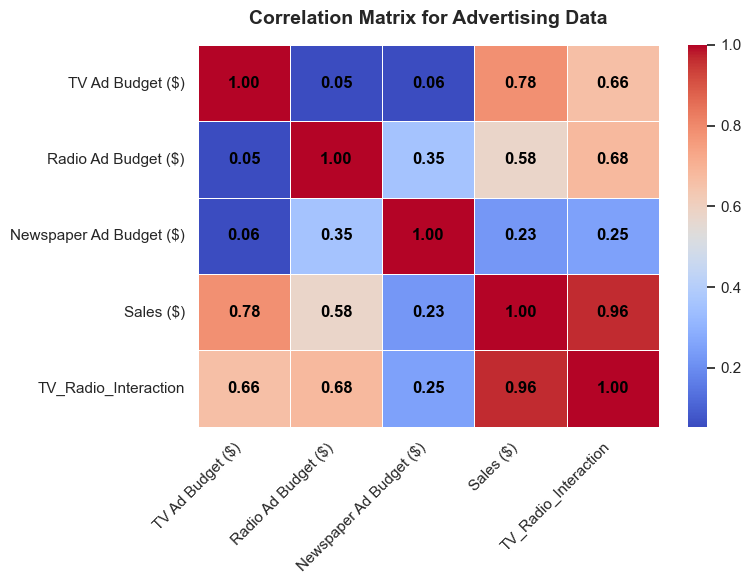

In [10]:
correlation = df.corr()
# 2. تحديد حجم لوحة الرسم البياني
plt.figure(figsize=(8, 6))

# 3. رسم الـ Heatmap مع تخصيص الـ annot_kws
sns.heatmap(
    correlation, 
    annot=True,              # لتفعيل إظهار أرقام نسب الارتباط داخل المربعات
    fmt=".2f",               # لتحديد تقريب الأرقام لخانة عشريتين فقط
    cmap="coolwarm",         # لاختيار تدريج ألوان مريح للعين (أزرق للارتباط السالب، أحمر للموجب)
    linewidths=0.5,          # لإضافة فواصل بيضاء خفيفة بين المربعات
    
    # هنا نقوم بتعديل شكل وحجم ولون الأرقام داخل المربعات:
    annot_kws={
        'size': 12,          # حجم خط الأرقام داخلياً
        'weight': 'bold',    # جعل الخط عريضاً وقابلاً للقراءة بسهولة
        'color': 'black'     # لون الخط (يمكنك تركه ليتغير تلقائياً حسب درجة لون المربع)
    }
)

# 4. إضافة عنوان وتعديل اتجاهات النصوص
plt.title("Correlation Matrix for Advertising Data", fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right') # تدوير مسميات المحور الأفقي حتى لا تتداخل
plt.yticks(rotation=0)

# 5. عرض الرسمة
plt.tight_layout()
plt.show()

In [4]:
# تقسيم البيانات إلى مجموعتي التدريب والاختبار (80% تدريب، 20% اختبار)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# =====================================================================
# 3. بناء خط المعالجة والتدريب (Pipeline & Training)
# =====================================================================
# تحديد نطاق واسع ودقيق لقيم الـ Alpha لنموذج Lasso
alphas_range = np.logspace(-4, 2, 100)

#

In [5]:
# إنشاء الـ Pipeline (التقييس أولاً ثم تطبيق النموذج)
pipeline = Pipeline([
    ('scaler', StandardScaler()), 
    ('lasso_cv', LassoCV(alphas=alphas_range, cv=5, random_state=42, max_iter=10000))
])

In [6]:
# تدريب النموذج بالكامل
pipeline.fit(X_train, y_train)

# =====================================================================
# 4. تقييم النموذج واستخراج المعاملات
# =====================================================================
y_pred = pipeline.predict(X_test)
lasso_model = pipeline.named_steps['lasso_cv']

In [7]:
print("="*50)
print(f"★ أفضل قيمة Alpha تم اختيارها تلقائياً: {lasso_model.alpha_:.6f}")
print(f"★ دقة النموذج الجديدة (R2 Score): {r2_score(y_test, y_pred):.4f}")
print(f"★ متوسط جذر الخطأ التربيعي (RMSE): {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")

★ أفضل قيمة Alpha تم اختيارها تلقائياً: 0.040370
★ دقة النموذج الجديدة (R2 Score): 0.9743
★ متوسط جذر الخطأ التربيعي (RMSE): 0.9013


In [9]:

# طباعة الأوزان والـ Bias
print("\n=== الأوزان المستخرجة (Weights & Bias) ===")
for name, coef in zip(X_train.columns, lasso_model.coef_):
    print(f"Weight ({name}): {coef:.4f}")
print(f"Bias (Intercept): {lasso_model.intercept_:.4f}")
print("="*50)


=== الأوزان المستخرجة (Weights & Bias) ===
Weight (TV Ad Budget ($)): 1.5690
Weight (Radio Ad Budget ($)): 0.4275
Weight (Newspaper Ad Budget ($)): 0.0091
Weight (TV_Radio_Interaction): 3.5476
Bias (Intercept): 14.1000


In [10]:
# =====================================================================
def predict_new_campaign(tv_budget, radio_budget, newspaper_budget):
    # بناء جدول مخصص وحساب المتغير التفاعلي تلقائياً
    custom_data = pd.DataFrame({
        'TV Ad Budget ($)': [tv_budget],
        'Radio Ad Budget ($)': [radio_budget],
        'Newspaper Ad Budget ($)': [newspaper_budget],
        'TV_Radio_Interaction': [tv_budget * radio_budget]
    })
    # التنبؤ باستخدام الـ pipeline
    prediction = pipeline.predict(custom_data)[0]
    return prediction

# مثال لتجربة حملة إعلانية جديدة:
custom_tv = 200.0
custom_radio = 40.0
custom_newspaper = 15.0

predicted_result = predict_new_campaign(custom_tv, custom_radio, custom_newspaper)
print(f"\n[تجربة اختبار المدخلات]")
print(f"عند إنفاق (TV: ${custom_tv}, Radio: ${custom_radio}, Newspaper: ${custom_newspaper})")
print(f"← المبيعات المتوقعة هي: ${predicted_result:.2f}")


[تجربة اختبار المدخلات]
عند إنفاق (TV: $200.0, Radio: $40.0, Newspaper: $15.0)
← المبيعات المتوقعة هي: $20.34


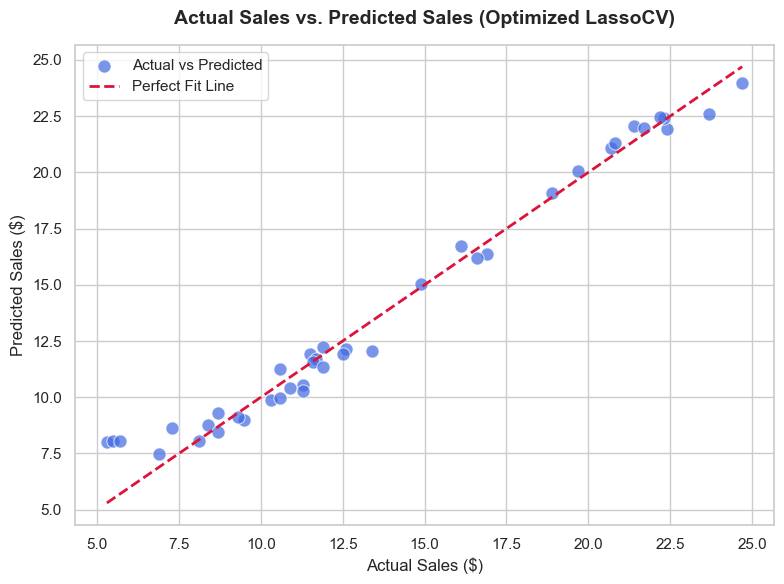

In [11]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 6))

# رسم النقاط الحقيقية ضد المتوقعة
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7, color='royalblue', edgecolor='w', s=90, label='Actual vs Predicted')

# رسم خط الملاءمة المثالي (زاوية 45 درجة)
min_val = min(min(y_test), min(y_pred))
max_val = max(max(y_test), max(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], color='crimson', linestyle='--', linewidth=2, label='Perfect Fit Line')

plt.title('Actual Sales vs. Predicted Sales (Optimized LassoCV)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Actual Sales ($)', fontsize=12)
plt.ylabel('Predicted Sales ($)', fontsize=12)
plt.legend(loc='upper left')
plt.tight_layout()

# عرض الرسم البياني
plt.show()